In [14]:
!pip install -q transformers[torch] kaggle

In [17]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"leonardotamanhao","key":"77816992cfc0ee589a14f207fe43fb13"}'}

In [39]:
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [40]:
!kaggle datasets download "marlesson/news-of-the-site-folhauol"
#!unzip news-of-the-site-folhauol.zip

Dataset URL: https://www.kaggle.com/datasets/marlesson/news-of-the-site-folhauol
License(s): CC0-1.0
 58% 109M/187M [00:00<00:00, 1.13GB/s]
100% 187M/187M [00:00<00:00, 781MB/s] 


In [153]:
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

df = pd.read_csv("news-of-the-site-folhauol.zip")
df.head(5)

,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem...",Com a possibilidade de uma condenação impedir ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
1,"'Decidi ser escrava das mulheres que sofrem', ...","Para Oumou Sangaré, cantora e ativista malines...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
2,Três reportagens da Folha ganham Prêmio Petrob...,Três reportagens da Folha foram vencedoras do ...,2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/192...
3,Filme 'Star Wars: Os Últimos Jedi' ganha trail...,A Disney divulgou na noite desta segunda-feira...,2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10...
4,CBSS inicia acordos com fintechs e quer 30% do...,"O CBSS, banco da holding Elopar dos sócios Bra...",2017-09-10,mercado,NaN,http://www1.folha.uol.com.br/mercado/2017/10/1...


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167053 entries, 0 to 167052
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   title        167053 non-null  object
 1   text         166288 non-null  object
 2   date         167053 non-null  object
 3   category     167053 non-null  object
 4   subcategory  29635 non-null   object
 5   link         167053 non-null  object
dtypes: object(6)
memory usage: 7.6+ MB


In [155]:
from transformers import BertForTokenClassification, DistilBertTokenizerFast, pipeline, AutoTokenizer
model = BertForTokenClassification.from_pretrained('monilouise/ner_pt_br')
tokenizer = DistilBertTokenizerFast.from_pretrained('neuralmind/bert-base-portuguese-cased'
                                                    , model_max_length=512
                                                    , do_lower_case=False
                                                    )
nlp = pipeline('ner', model=model, tokenizer=tokenizer, grouped_entities=True)

Some weights of the model checkpoint at monilouise/ner_pt_br were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BertTokenizer'. 
The class this function is called from is 'DistilBertTokenizer'.
The tokenizer class you load from this check

In [156]:
#get category mercado and first trismestre of 2015
market_df = df.loc[(df['category'] == 'mercado') & (df['date'] >= '2015-01-01') & (df['date'] <= '2015-03-31')]
market_df

,title,text,date,category,subcategory,link
99055,Prioridade ao pós-pago reduz número de linhas ...,"O mercado de telefonia celular perdeu 2,09 mil...",2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...
99063,Dilma sanciona meta fiscal e governo liberará ...,A presidente Dilma Rousseff sancionou a altera...,2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...
99064,Reportagem da Folha sobre investidor mais jove...,"A reportagem da Folha ""Príncipe da Bolsa"", de ...",2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...
99074,Impeachment pode prejudicar ajuste fiscal no B...,A abertura do processo de impeachment da presi...,2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...
99076,Petrobras anuncia 2º reajuste no preço do gás ...,A Petrobras comunicou ao mercado novo reajuste...,2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...
...,...,...,...,...,...,...
167000,"Em Miami, brasileiros gastam mais com compras ...",Chamam a atenção no caso do Brasil os gastos e...,2015-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/01/1...
167004,25% dos municípios brasileiros fecharam vagas ...,Cerca de um quarto dos municípios brasileiros ...,2015-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/01/1...
167013,Brasileiros lideram em número de turistas que ...,"""Em 2013, 51% dos turistas que foram a Miami e...",2015-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/01/1...
167016,Brasil só vai entrar nos eixos se fizer reform...,Em uma analogia entre a gestão pública e a emp...,2015-01-01,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/01/1...


In [157]:
#remove stop words from text
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
stop = stopwords.words('portuguese')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [158]:
def remove_stopwords(text):
  text = ' '.join([word for word in text.split() if word not in (stop)])
  return text

market_df["cleaned_text"] = market_df["text"].progress_apply(remove_stopwords)
market_df.head(5)

  0%|          | 0/2111 [00:00<?, ?it/s]

/tmp/ipython-input-158-3546119224.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  market_df["cleaned_text"] = market_df["text"].progress_apply(remove_stopwords)


,title,text,date,category,subcategory,link,cleaned_text
99055,Prioridade ao pós-pago reduz número de linhas ...,"O mercado de telefonia celular perdeu 2,09 mil...",2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,"O mercado telefonia celular perdeu 2,09 milhõe..."
99063,Dilma sanciona meta fiscal e governo liberará ...,A presidente Dilma Rousseff sancionou a altera...,2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,A presidente Dilma Rousseff sancionou alteraçã...
99064,Reportagem da Folha sobre investidor mais jove...,"A reportagem da Folha ""Príncipe da Bolsa"", de ...",2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,"A reportagem Folha ""Príncipe Bolsa"", autoria D..."
99074,Impeachment pode prejudicar ajuste fiscal no B...,A abertura do processo de impeachment da presi...,2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,A abertura processo impeachment presidente Dil...
99076,Petrobras anuncia 2º reajuste no preço do gás ...,A Petrobras comunicou ao mercado novo reajuste...,2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,A Petrobras comunicou mercado novo reajuste pr...


In [163]:
#merge the token with the previous if starts with ##
def merge_subtokens(entities):
    merged = []
    for ent in entities:
        if ent['word'].startswith("##") and merged:
            prev = merged[-1]
            # Une apenas se estiverem colados no texto
            if ent['start'] == prev['end']:
                prev['word'] += ent['word'][2:]
                prev['score'] = (prev['score'] + ent['score']) / 2
                prev['end'] = ent['end']
            else:
                merged.append(ent)
        else:
            merged.append(ent)
    return merged


#get all entities of type org
def get_entities(text):
    result = nlp(text)
    result = merge_subtokens(result)
    result = [ent['word'] for ent in result if ent['entity_group'] == 'ORG']
    return result

market_df["entities"] = market_df["text"].progress_apply(get_entities)
market_df.head(5)

  0%|          | 0/2111 [00:00<?, ?it/s]

/tmp/ipython-input-163-957810401.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  market_df["entities"] = market_df["text"].progress_apply(get_entities)


,title,text,date,category,subcategory,link,cleaned_text,entities
99055,Prioridade ao pós-pago reduz número de linhas ...,"O mercado de telefonia celular perdeu 2,09 mil...",2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,"O mercado telefonia celular perdeu 2,09 milhõe...","[Claro, grupo, América, Móvil, TIM, Oi, Vivo, ..."
99063,Dilma sanciona meta fiscal e governo liberará ...,A presidente Dilma Rousseff sancionou a altera...,2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,A presidente Dilma Rousseff sancionou alteraçã...,[]
99064,Reportagem da Folha sobre investidor mais jove...,"A reportagem da Folha ""Príncipe da Bolsa"", de ...",2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,"A reportagem Folha ""Príncipe Bolsa"", autoria D...","[Folha, BM &, ##pa, Jornal do, Comércio "", Agê..."
99074,Impeachment pode prejudicar ajuste fiscal no B...,A abertura do processo de impeachment da presi...,2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,A abertura processo impeachment presidente Dil...,"[Fitch, Fi, Folha]"
99076,Petrobras anuncia 2º reajuste no preço do gás ...,A Petrobras comunicou ao mercado novo reajuste...,2015-03-12,mercado,NaN,http://www1.folha.uol.com.br/mercado/2015/12/1...,A Petrobras comunicou mercado novo reajuste pr...,[]


In [175]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
organizations = market_df["entities"].tolist()
#flatten list
orgs = [item for sublist in organizations for item in sublist]

#remove the separated letters from the 'parent' entity like Moody's or S & P
normalized_orgs = []
for org in orgs:
    if org in ["s", "O", "P"]:
        continue  # ignora essas entidades
    elif org == "Moody '":
        normalized_orgs.append("Moody's")
    elif org == "OAS":
        normalized_orgs.append("OAS")
    elif org == "S &":
        normalized_orgs.append("S & P")
    else:
        normalized_orgs.append(org)

In [176]:
counter = Counter(normalized_orgs).most_common(15)
counter

[('Folha', 514),
 ('Brasil', 141),
 ('Sete', 105),
 ('HSBC', 102),
 ('Bradesco', 97),
 ('OAS', 84),
 ("Moody's", 78),
 ('Google', 71),
 ('Oi', 70),
 ('Bloomberg', 67),
 ('Itaú', 66),
 ('S & P', 63),
 ('Investimentos', 56),
 ('Vale', 56),
 ('FGV', 54)]

/tmp/ipython-input-185-798397966.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette="cividis")


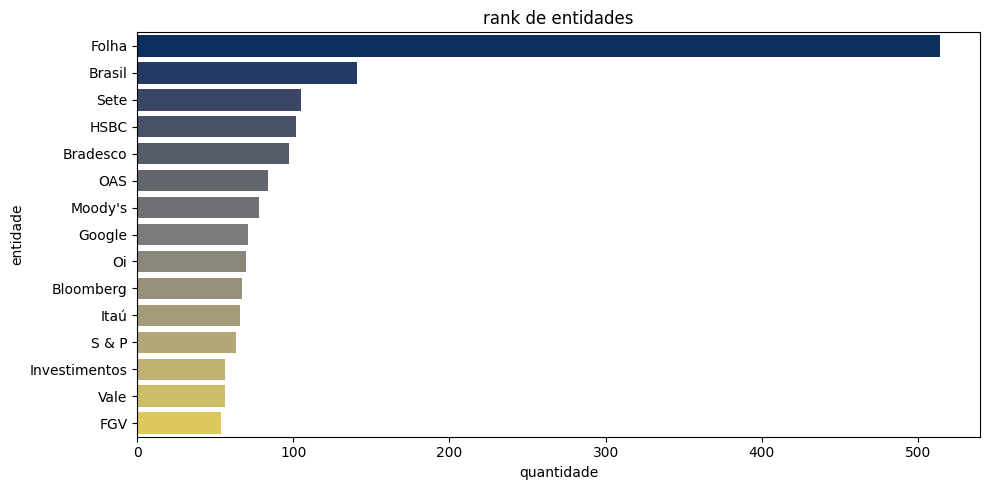

In [185]:
labels, values = zip(*counter)
plt.figure(figsize=(10, 5))
sns.barplot(x=values, y=labels, palette="cividis")
plt.xlabel("quantidade")
plt.ylabel("entidade")
plt.title("rank de entidades")
plt.tight_layout()
plt.show()

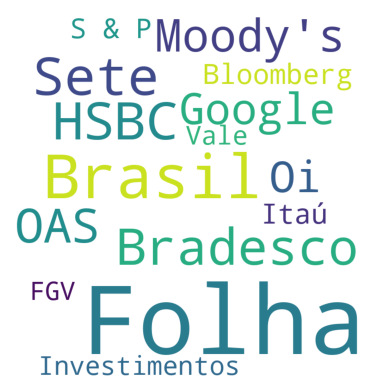

In [191]:
from wordcloud import WordCloud

text_freq = dict(zip(labels, values))
wordcloud = WordCloud(width=800, height=800, background_color='white').generate_from_frequencies(text_freq)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [ ]:
#descobre as letras perdidas
mask = market_df["entities"].apply(lambda ents: 'P' in ents)
suspect_rows = market_df[mask]

for idx, row in suspect_rows.iterrows():
    print("texto:", row["text"])
    print("entidades:", row["entities"])
    print("---")